In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
model_path = "region_classifier_new.pth"
data_path = "data"
batch_size = 32
num_workers = 4
random_seed = 42

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])


val_data = torchvision.datasets.ImageFolder(
    root="final_split_data/val",
    transform=transform
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=4
)


In [4]:
class CNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # output: [B, 64, 1, 1]
            nn.Flatten(),                  # output: [B, 64]
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.ReLU(inplace=True),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load(model_path, map_location=device, weights_only=False)
model = model.to(device)
model.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=128, out_features=128, bias=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=128

In [6]:
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Running validation"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)                   # raw logits
        probs = torch.softmax(outputs, dim=1)    # convert to probabilities

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

Running validation: 100%|██████████| 72/72 [00:26<00:00,  2.72it/s]


In [7]:
def plot_multi_roc(results_dict, 
                  figsize=(6, 5),
                  colors=None,
                  zoom_factor=5,
                  zoom_location=2,
                  zoom_bbox=(0.5, 0.9),
                  zoom_xlim=(0, 0.1),
                  zoom_ylim=(0.9, 1.0),
                  show_std=True,
                  xlabel_size=18,
                  ylabel_size=18,
                  tick_size=14,
                  legend_size=13,
                  inset_tick_size=11):
    import matplotlib.pyplot as plt
    import numpy as np
    from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
    
    if colors is None:
        colors = ['#8b91c1', '#d9a9cd', '#424874', '#e6d3ae', '#7aa6c2', '#c27a7a']
    
    fig = plt.figure(figsize=figsize)
    ax = plt.gca()
    
    for idx, (model_name, results) in enumerate(results_dict.items()):
        color = colors[idx % len(colors)]
        
        mean_fpr = results['mean_fpr']
        mean_tpr = results['mean_tpr']
        mean_auc = results['mean_auc']
        
        ax.plot(mean_fpr, mean_tpr, color=color,
                label=f'{model_name} (AUC = {mean_auc:.4f})',
                lw=2, alpha=0.8)
        
        if show_std and 'std_tpr' in results and 'std_auc' in results:
            std_tpr = results['std_tpr']
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            ax.fill_between(mean_fpr, tprs_lower, tprs_upper, 
                            color=color, alpha=0.2)
    
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_xlabel('1 - Specificity', fontsize=xlabel_size)
    ax.set_ylabel('Sensitivity', fontsize=ylabel_size)
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.legend(loc="lower right", fontsize=legend_size)
    
    axins = zoomed_inset_axes(ax, zoom_factor, loc=zoom_location, 
                              bbox_to_anchor=zoom_bbox, 
                              bbox_transform=ax.transAxes)
    
    for idx, (model_name, results) in enumerate(results_dict.items()):
        color = colors[idx % len(colors)]
        mean_fpr = results['mean_fpr']
        mean_tpr = results['mean_tpr']
        
        axins.plot(mean_fpr, mean_tpr, color=color, lw=2)
        
        if show_std and 'std_tpr' in results:
            std_tpr = results['std_tpr']
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            axins.fill_between(mean_fpr, tprs_lower, tprs_upper, 
                               color=color, alpha=0.2)
    
    axins.set_xlim(zoom_xlim)
    axins.set_ylim(zoom_ylim)
    
    xticks = np.linspace(zoom_xlim[0], zoom_xlim[1], 3)
    yticks = np.linspace(zoom_ylim[0], zoom_ylim[1], 3)
    axins.set_xticks(xticks)
    axins.set_yticks(yticks)
    axins.tick_params(axis='both', labelsize=inset_tick_size)
    
    plt.tight_layout()
    
    return fig, ax, axins

In [ ]:
y_true_bin = label_binarize(all_labels, classes=np.arange(len(val_data.classes)))

results_dict = {}

for i, class_name in enumerate(val_data.classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    results_dict[class_name.capitalize()] = {
        "mean_fpr": fpr,
        "mean_tpr": tpr,
        "mean_auc": roc_auc
    }

C:\Users\ethan\AppData\Local\Temp\ipykernel_3848\3926162558.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


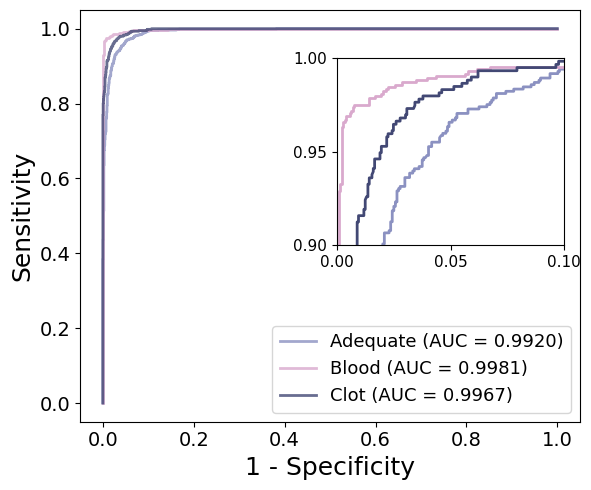

In [11]:
fig, ax, axins = plot_multi_roc(results_dict)

plt.show()